In [1]:
from src.backend import TorchBackend
from src.model import Uniform, Rectangle, Ellipse, Material, Lattice, Bitmap, Layer, Source, Model
from src.solver import Solver, Config

import torch
import numpy as np
import matplotlib.pyplot as plt

In [5]:
""" Define base settings"""
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)

period = (500, 500)
grid = (501, 501)
M, N = 41, 41

lattice = Lattice(period, grid, M, N)

wavelenghts = torch.tensor([400.0, 500.0, 600.0, 700.0, 800.0])
theta = torch.tensor([0.0, 10.0, 20.0, 30.0, 40.0])*np.pi/180
phi = torch.tensor([0.0])*np.pi/180

source = Source(wavelenghts, theta, phi)

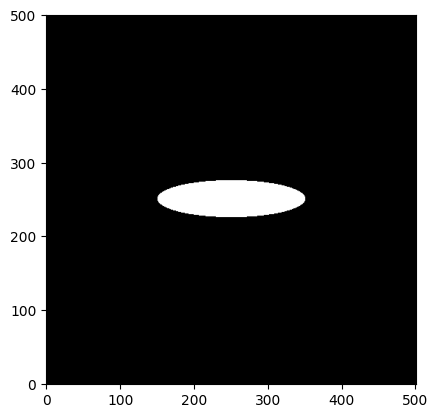

In [10]:
""" Build model"""

# Input layer
epsilon_in = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0])
mat_in = Material(epsilon_in)
obj_in = Uniform(mat_in)
layer_in = Layer(obj_in, None, mat_in)

# Output layer
epsilon_out = torch.tensor([1.46**2, 1.46**2, 1.46**2, 1.46**2, 1.46**2])
mat_out = Material(epsilon_out)
obj_out = Uniform(mat_out)
layer_out = Layer(obj_out, None, mat_out)

# Layers
epsilon_1 = torch.tensor([4.0**2, 4.0**2, 4.0**2, 4.0**2, 4.0**2])
epsilon_1_bg = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0])
d_1 = torch.tensor([200.0])
center1 = torch.tensor([0.0, 0.0])
size = torch.tensor([200.0, 50.0])
angle = torch.tensor(0.0)*np.pi/180
obj1 = Ellipse(center1, size, Material(epsilon_1), angle=angle, soft_mask=False, smoothness=0.02)
layer1 = Layer(obj1, d_1, Material(epsilon_1_bg))
plt.imshow(layer1.bitmap(backend, lattice).squeeze().cpu().T, origin='lower', cmap='gray')

layers = [layer_in, layer1, layer_out]

model = Model(backend, lattice, layers, source)


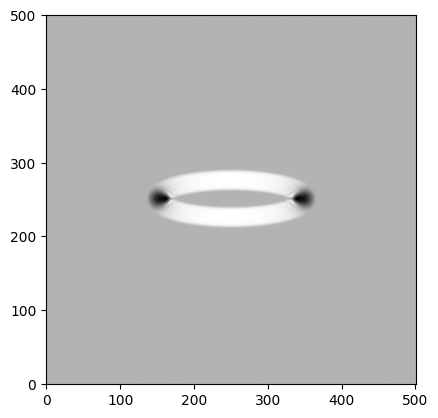

In [11]:
""" Create config """
cfg = Config(solver='python', 
             use_grads=False,
             closed_form=False,
             circ_truncation=False,
             inverse_regularization=1e-8,
             inverse_matrix_method='solve',
             factorization='Jones',
             tvf_optimizer='LBFGS',
             tvf_alpha=1.0,
             tvf_beta=1e-6,
             tvf_gamma=0.0,
             tvf_steps=1,
             modes_solver='eig',
             hsimplify=True,
             smlayer='Numerical')

""" Create solver """
solver = Solver([model, model], cfg)

inp = solver._prepare_solver_inputs([((0, 0), 1.0 + 0.0j, 0.0 + 0.0j)])
Tx = inp['models'][0][1]['tvf'][0].squeeze(0).cpu()
Ty = inp['models'][0][1]['tvf'][1].squeeze(0).cpu()


plt.imshow(Tx.real.T, origin='lower', cmap='gray')

(60.0, 100.0)

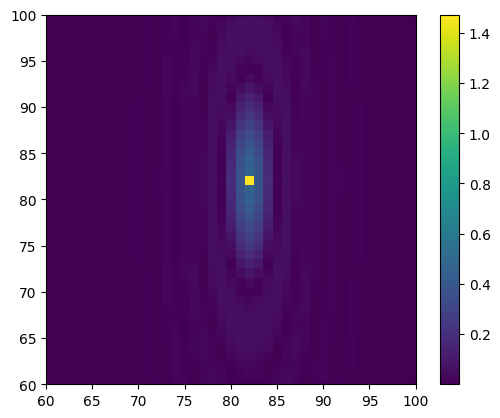

In [12]:
plt.imshow((inp['models'][0][1]['epsilon'].abs().cpu()[0,0,0].T), origin='lower')
plt.colorbar()
plt.xlim([60, 100])
plt.ylim([60, 100])

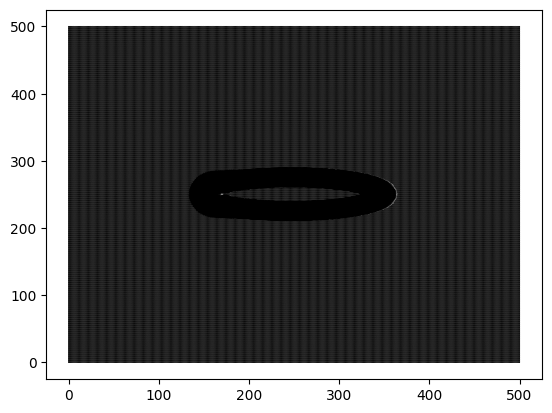

In [14]:
plt.quiver(Tx.T, Ty.T, scale=30)
# plt.xlim([40, 90])
# plt.ylim([40, 90])

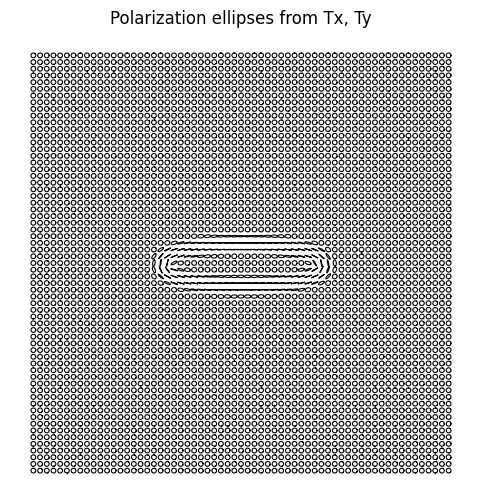

In [21]:
S0 = np.abs(Tx.T.numpy())**2 + np.abs(Ty.T.numpy())**2
S1 = np.abs(Tx.T.numpy())**2 - np.abs(Ty.T.numpy())**2
S2 = 2 * np.real(Tx.T.numpy() * np.conj(Ty.T.numpy()))
S3 = -2 * np.imag(Tx.T.numpy() * np.conj(Ty.T.numpy()))   # IEEE / optics convention

# orientation of ellipse (angle of major axis)
psi = 0.5 * np.arctan2(S2, S1)

# ellipticity angle
chi = 0.5 * np.arcsin(np.clip(S3 / (S0 + 1e-12), -1.0, 1.0))

def draw_ellipse(x0, y0, psi, chi, scale=0.4, n=60, color="k"):
    """
    Draw polarization ellipse.
    psi : orientation angle
    chi : ellipticity angle
    """
    t = np.linspace(0, 2*np.pi, n)

    # semi-axes
    a = scale * np.cos(chi)   # major
    b = scale * np.sin(chi)   # minor

    # parametric ellipse
    x = a * np.cos(t)
    y = b * np.sin(t)

    # rotate by psi
    R = np.array([[np.cos(psi), -np.sin(psi)],
                  [np.sin(psi),  np.cos(psi)]])
    xy = R @ np.vstack([x, y])

    plt.plot(x0 + xy[0], y0 + xy[1], color=color, lw=0.8)
    
Nx, Ny = Tx.shape
step = 8        # increase if dense
scale = 4    # ellipse size

plt.figure(figsize=(6, 6))

for i in range(0, Nx, step):
    for j in range(0, Ny, step):
        if S0[i, j] < 1e-12:
            continue  # skip empty points
        draw_ellipse(
            x0=j,
            y0=i,
            psi=psi[i, j],
            chi=chi[i, j],
            scale=scale
        )

plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()   # optional, matches image coordinates
plt.title("Polarization ellipses from Tx, Ty")
plt.axis("off")
# plt.xlim([40, 90])
# plt.ylim([40, 90])
plt.show()